# 12 - Benchmark Karşılaştırması: OPS-SAT Baseline

---
## Bölüm 1: Referans Baseline ve Sonuçları Yükle


In [1]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, os.path.join('..', 'src'))
from benchmark_reference import (PAPER_BASELINE, NAME_MAP, PAPER_CATEGORY,
                                 APPROXIMATE_MATCHES)
from metrics import BENCHMARK_METRICS

with open('../reports/metrics/final_comparison.json') as f:
    OURS = json.load(f)

PARADIGM_MISMATCH = {'KNN'}

print(f'Makale baseline: {len(PAPER_BASELINE)} algoritma (Tablo 3)')
print(f'Sonuç: {len(OURS)} model (resmi Ψ, 7 metrik)')
print(f'Metrikler: {BENCHMARK_METRICS}')


Makale baseline: 30 algoritma (Tablo 3)
Sonuç: 42 model (resmi Ψ, 7 metrik)
Metrikler: ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC', 'AUC_ROC', 'AUC_PR']


In [2]:
def build_comparison():
    rows = []
    for pname, pm in PAPER_BASELINE.items():
        oname = NAME_MAP.get(pname)
        if not oname or oname not in OURS:
            continue
        om = OURS[oname]
        flag = ''
        if pname in APPROXIMATE_MATCHES: flag += '~'
        if pname in PARADIGM_MISMATCH:   flag += '!'
        rows.append({
            'Algoritma': pname + flag,
            'Kategori': PAPER_CATEGORY[pname],
            'Paper_AUC_PR': pm['AUC_PR'], 'Bizim_AUC_PR': round(om['AUC_PR'], 3),
            'ΔAUC_PR': round(om['AUC_PR'] - pm['AUC_PR'], 3),
            'Paper_F1': pm['F1'], 'Bizim_F1': round(om['F1'], 3),
            'ΔF1': round(om['F1'] - pm['F1'], 3),
            'Paper_MCC': pm['MCC'], 'Bizim_MCC': round(om['MCC'], 3),
            'ΔMCC': round(om['MCC'] - pm['MCC'], 3),
        })
    return pd.DataFrame(rows)

cmp_df = build_comparison()
print(f"Eşleşen algoritma: {len(cmp_df)}/{len(PAPER_BASELINE)}")
print(f"Eşleşmeyen (bizde yok): "
      f"{[p for p in PAPER_BASELINE if NAME_MAP.get(p) not in OURS]}")


Eşleşen algoritma: 22/30
Eşleşmeyen (bizde yok): ['MO-GAAL', 'AnoGAN', 'SO-GAAL', 'ALAD', 'LUNAR', 'DIF', 'VAE', 'DeepSVDD']


---
## Bölüm 2: Gözetimli Algoritmalar, Reprodüksiyon Karşılaştırması

In [3]:
sup = cmp_df[cmp_df['Kategori'] == 'Gozetimli'].sort_values('Paper_AUC_PR', ascending=False)
disp_cols = ['Algoritma', 'Paper_AUC_PR', 'Bizim_AUC_PR', 'ΔAUC_PR',
             'Paper_F1', 'Bizim_F1', 'ΔF1', 'Paper_MCC', 'Bizim_MCC', 'ΔMCC']
display(sup[disp_cols].style.background_gradient(
    cmap='RdYlGn', subset=['ΔAUC_PR', 'ΔF1', 'ΔMCC'], vmin=-0.1, vmax=0.1).format(
    {c: '{:.3f}' for c in disp_cols if c != 'Algoritma'}))

mae = sup['ΔAUC_PR'].abs().mean()
print(f"\nGözetimli reprodüksiyon - ortalama |diff AUC_PR|: {mae:.4f}")
print(f"  Birebir ya da üstün (diff AUC_PR >= -0.01): {(sup['ΔAUC_PR'] >= -0.01).sum()}/{len(sup)}")


,Algoritma,Paper_AUC_PR,Bizim_AUC_PR,ΔAUC_PR,Paper_F1,Bizim_F1,ΔF1,Paper_MCC,Bizim_MCC,ΔMCC
0,FCNN~,0.979,0.979,0.000,0.946,0.946,-0.000,0.932,0.932,-0.000
1,XGBOD,0.975,0.973,-0.002,0.918,0.922,0.004,0.897,0.903,0.006
2,RF+ICCS~,0.963,0.967,0.004,0.883,0.911,0.028,0.862,0.891,0.029
3,LSVC,0.934,0.929,-0.005,0.808,0.792,-0.016,0.771,0.765,-0.006
4,LR,0.931,0.927,-0.004,0.800,0.772,-0.028,0.764,0.733,-0.031
5,AdaBoost,0.923,0.933,0.010,0.836,0.832,-0.004,0.797,0.791,-0.006
6,Linear+L2~,0.901,0.905,0.004,0.722,0.723,0.001,0.703,0.687,-0.016



Gözetimli reprodüksiyon - ortalama |diff AUC_PR|: 0.0041
  Birebir ya da üstün (diff AUC_PR >= -0.01): 7/7


---
## Bölüm 3: Gözetimsiz Algoritmalar, Karşılaştırma ve Farklar

In [5]:
uns = cmp_df[cmp_df['Kategori'] == 'Gozetimsiz'].sort_values('Paper_AUC_PR', ascending=False)
display(uns[disp_cols].style.background_gradient(
    cmap='RdYlGn', subset=['ΔAUC_PR', 'ΔF1', 'ΔMCC'], vmin=-0.2, vmax=0.2).format(
    {c: '{:.3f}' for c in disp_cols if c != 'Algoritma'}))

uns_clean = uns[~uns['Algoritma'].str.contains('!')]
print(f"\nGözetimsiz (paradigma farkı hariç {len(uns_clean)} model):")
print(f"  Güncel >= paper (ΔAUC_PR ≥ 0): {(uns_clean['ΔAUC_PR'] >= 0).sum()}/{len(uns_clean)}")
print(f"  Ortalama ΔAUC_PR: {uns_clean['ΔAUC_PR'].mean():+.3f}")
print(f"\nEn büyük pozitif/negatif Δ:")
print(f"  En iyi : {uns_clean.loc[uns_clean['ΔAUC_PR'].idxmax(), 'Algoritma']} "
      f"({uns_clean['ΔAUC_PR'].max():+.3f})")
print(f"  En kötü: {uns_clean.loc[uns_clean['ΔAUC_PR'].idxmin(), 'Algoritma']} "
      f"({uns_clean['ΔAUC_PR'].min():+.3f})")


,Algoritma,Paper_AUC_PR,Bizim_AUC_PR,ΔAUC_PR,Paper_F1,Bizim_F1,ΔF1,Paper_MCC,Bizim_MCC,ΔMCC
7,OCSVM,0.659,0.448,-0.211,0.647,0.438,-0.209,0.548,0.292,-0.256
8,KNN!,0.658,0.910,0.252,0.575,0.870,0.295,0.465,0.844,0.379
9,ABOD,0.644,0.642,-0.002,0.582,0.577,-0.005,0.479,0.464,-0.015
10,INNE,0.643,0.505,-0.138,0.646,0.598,-0.048,0.549,0.485,-0.064
11,LMDD,0.623,0.322,-0.301,0.628,0.084,-0.544,0.542,0.162,-0.380
12,SOD,0.621,0.589,-0.032,0.505,0.502,-0.003,0.348,0.340,-0.008
13,COF,0.603,0.609,0.006,0.576,0.581,0.005,0.448,0.457,0.009
14,LODA,0.597,0.365,-0.232,0.588,0.279,-0.309,0.475,0.096,-0.379
15,CBLOF,0.493,0.422,-0.071,0.427,0.438,0.011,0.272,0.279,0.007
16,GMM,0.426,0.351,-0.075,0.393,0.283,-0.110,0.225,0.096,-0.129



Gözetimsiz (paradigma farkı hariç 14 model):
  Güncel >= paper (ΔAUC_PR ≥ 0): 6/14
  Ortalama ΔAUC_PR: -0.071

En büyük pozitif/negatif Δ:
  En iyi : PCA (+0.038)
  En kötü: LMDD (-0.301)


---
## Bölüm 4: Görselleştirme


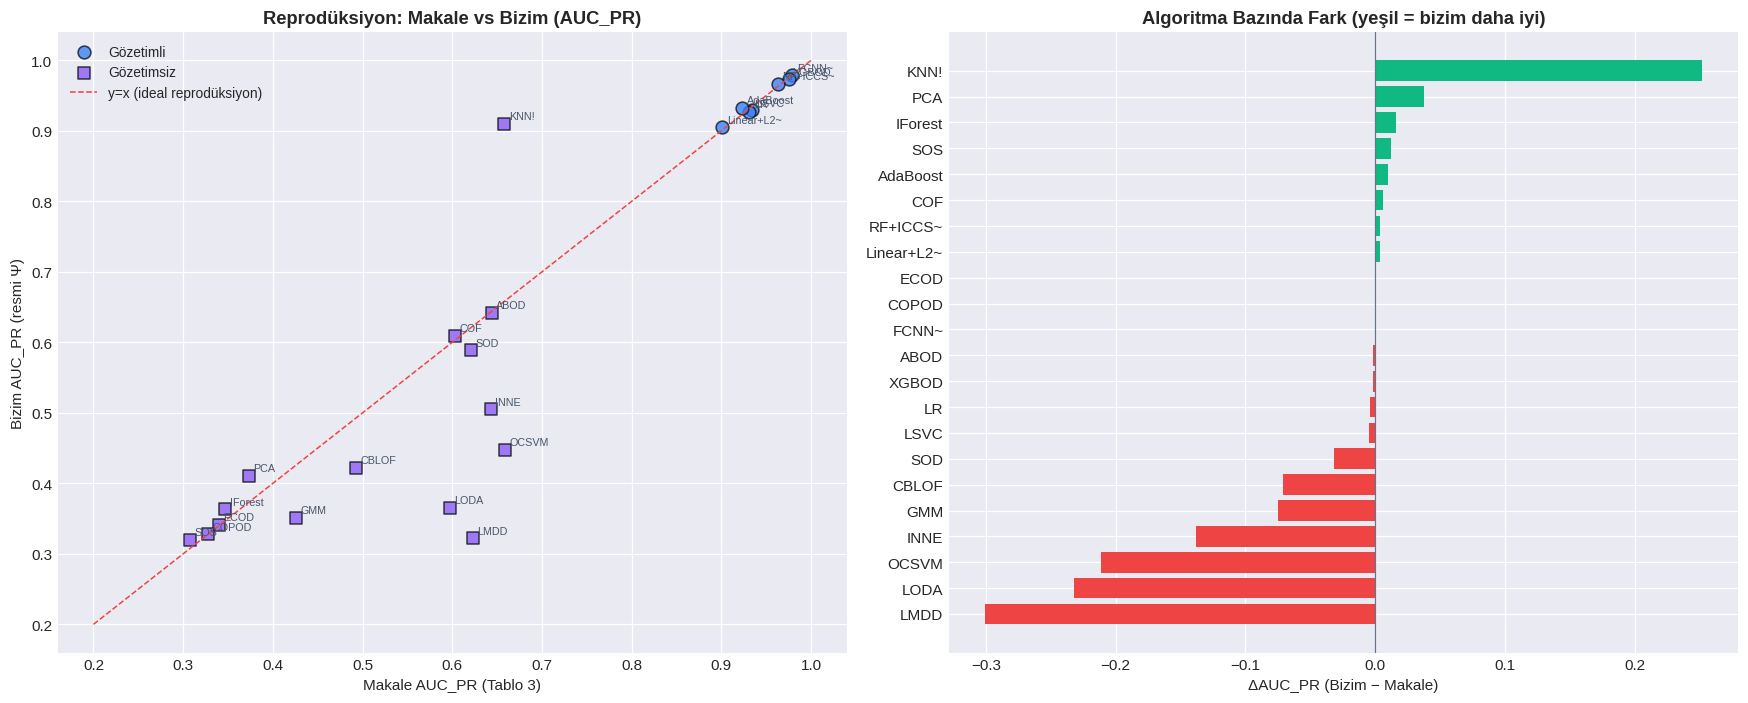

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

ax = axes[0]
for cat, color, mark in [('Gozetimli', '#3B82F6', 'o'), ('Gozetimsiz', '#8B5CF6', 's')]:
    sub = cmp_df[cmp_df['Kategori'] == cat]
    ax.scatter(sub['Paper_AUC_PR'], sub['Bizim_AUC_PR'], s=70, color=color,
               marker=mark, alpha=0.8, edgecolors='#0D1117',
               label='Gözetimli' if cat == 'Gozetimli' else 'Gözetimsiz')
    for _, r in sub.iterrows():
        ax.annotate(r['Algoritma'], (r['Paper_AUC_PR'], r['Bizim_AUC_PR']),
                    fontsize=7, color='#475569', xytext=(3, 3), textcoords='offset points')
lims = [0.2, 1.0]
ax.plot(lims, lims, '--', color='#EF4444', lw=1, label='y=x (ideal reprodüksiyon)')
ax.set_xlabel('Makale AUC_PR (Tablo 3)'); ax.set_ylabel('Bizim AUC_PR (resmi Ψ)')
ax.set_title('Reprodüksiyon: Makale vs Bizim (AUC_PR)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
d = cmp_df.sort_values('ΔAUC_PR')
colors = ['#10B981' if v >= 0 else '#EF4444' for v in d['ΔAUC_PR']]
ax.barh(d['Algoritma'], d['ΔAUC_PR'], color=colors)
ax.axvline(0, color='#64748B', lw=0.8)
ax.set_xlabel('ΔAUC_PR (Bizim − Makale)')
ax.set_title('Algoritma Bazında Fark (yeşil = bizim daha iyi)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/benchmark_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Bölüm 5: Bulgular ve Yorum


In [7]:
sup_mae = sup['ΔAUC_PR'].abs().mean()
print(f'Eşleşen algoritma           : {len(cmp_df)}/{len(PAPER_BASELINE)}')
print(f'Gözetimli reprodüksiyon MAE : {sup_mae:.4f} AUC_PR (sıfıra yakın = sadık)')
print(f'En iyi gözetimli (bizim)    : '
      f"{cmp_df.loc[cmp_df['Bizim_AUC_PR'].idxmax(), 'Algoritma']} "
      f"(AUC_PR={cmp_df['Bizim_AUC_PR'].max():.3f})")


Eşleşen algoritma           : 22/30
Gözetimli reprodüksiyon MAE : 0.0041 AUC_PR (sıfıra yakın = sadık)
En iyi gözetimli (bizim)    : FCNN~ (AUC_PR=0.979)


---
## Bölüm 6: Kaydetme
Karşılaştırma tablosunu CSV olarak dışa aktarıyoruz.


In [9]:
os.makedirs('../reports/metrics', exist_ok=True)
out = '../reports/metrics/benchmark_comparison.csv'
cmp_df.to_csv(out, index=False)
print(f'Benchmark karşılaştırma tablosu kaydedildi -> {out}')
print(f'Boyut: {cmp_df.shape[0]} algoritma x {cmp_df.shape[1]} sütun')


Benchmark karşılaştırma tablosu kaydedildi -> ../reports/metrics/benchmark_comparison.csv
Boyut: 22 algoritma x 11 sütun
